In [1]:
#import pandas and load data
import pandas as pd
df = pd.read_csv("/content/yelp_review.csv")

print(df.shape)
df.head()

(100000, 9)


,stars,useful,text,funny,review_id,cool,date,user_id,business_id
0,4.0,0,First time waxing. I read all the other review...,0,V46usAbOSPIzurZy7DUU5A,0,2016-04-16 13:55:38,rD6noiuiMCcGuq6oPYFJdQ,b4NaB1u3AwgrhRMKsKgWsA
1,5.0,0,I love my manicure! Such an affordable place. ...,0,CpNSsju9NFc-Xrpf5Hfqhg,0,2020-01-18 05:32:54,tTsUSklzH1oxPp2usth84A,-otKp6RA94dfGsqa5jSDHQ
2,4.0,0,"Great food, fast service, they try to crank pe...",0,RP7A24xD14Cbegmr1AokNQ,0,2015-01-25 14:49:09,-cnIq2OmV8CleS4bLOvCxQ,EA10YCkaxzRoCEOB38xv1Q
3,1.0,0,Save your money and go across the street the f...,0,6a38lS1TjeWMqK-knuNAhA,0,2018-11-06 22:12:14,mzCkRflEka_vezCiBYYWGA,nkqaLepNTSrUYuZkzbBR5A
4,4.0,0,Oops...this was for the Main St location:\n\n-...,0,Q0QKTuceHzgmFeTtYSTzYg,0,2011-08-19 21:45:31,3zlK9eBVCpRWMPLjtAj6cQ,XtFhLvKV46H7a054X2_aFQ


In [2]:
#check columns and missing values
print(df.columns)
print()
print(df.isna().sum())

Index(['stars', 'useful', 'text', 'funny', 'review_id', 'cool', 'date',
       'user_id', 'business_id'],
      dtype='object')

stars          0
useful         0
text           0
funny          0
review_id      0
cool           0
date           0
user_id        0
business_id    0
dtype: int64


In [3]:
#keep useful columns only
df = df[["stars", "text"]].copy()

print(df.shape)
df.head()

(100000, 2)


,stars,text
0,4.0,First time waxing. I read all the other review...
1,5.0,I love my manicure! Such an affordable place. ...
2,4.0,"Great food, fast service, they try to crank pe..."
3,1.0,Save your money and go across the street the f...
4,4.0,Oops...this was for the Main St location:\n\n-...


In [4]:
#clean text
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)
df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,clean_text
0,First time waxing. I read all the other review...,first time waxing read reviews decided trust y...
1,I love my manicure! Such an affordable place. ...,love manicure affordable place manicurist kind...
2,"Great food, fast service, they try to crank pe...",great food fast service try crank people fast ...
3,Save your money and go across the street the f...,save money across street food way better taqui...
4,Oops...this was for the Main St location:\n\n-...,oops main location visited aladdin way columbu...


In [5]:
#ompare original and cleaned text
print("Original review:")
print(df["text"].iloc[0][:500])
print("\nCleaned review:")
print(df["clean_text"].iloc[0][:500])

Original review:
First time waxing. I read all the other reviews and decided to trust yelp. Not disappointed. It was extremely fast and even though it was a little painful I am sure it would have been worse elsewhere. Great customer service, I will be going back.

Cleaned review:
first time waxing read reviews decided trust yelp disappointed extremely fast even though little painful sure would worse elsewhere great customer service going back


In [6]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=5)
X = vectorizer.fit_transform(df["clean_text"])

print(X.shape)

(100000, 3000)


In [7]:
#cluster
from sklearn.cluster import KMeans
k = 6
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10)
df["cluster"] = kmeans.fit_predict(X)

df["cluster"].value_counts().sort_index()

,count
cluster,
0,34871
1,2725
2,23333
3,18916
4,3388
5,16767


In [8]:
#key terms cluster
terms = vectorizer.get_feature_names_out()
for i in range(k):
    center = kmeans.cluster_centers_[i]
    top_idx = center.argsort()[-12:][::-1]
    top_words = [terms[j] for j in top_idx]

    print(f"\nCluster {i}")
    print(", ".join(top_words))


Cluster 0
place, great, love, staff, best, always, like, good, friendly, get, one, coffee

Cluster 1
pizza, crust, good, place, great, cheese, pizzas, sauce, order, best, toppings, slice

Cluster 2
good, chicken, food, ordered, place, like, really, sauce, delicious, got, menu, also

Cluster 3
time, would, car, service, get, back, one, told, customer, said, never, minutes

Cluster 4
highly, highly recommend, recommend, great, would highly, place, amazing, service, would, food, friendly, best

Cluster 5
food, great, service, good, place, restaurant, delicious, amazing, great food, atmosphere, back, friendly


In [9]:
#raiting per cluster
cluster_rating = df.groupby("cluster")["stars"].agg(["mean", "count"]).sort_values("mean")

cluster_rating

,mean,count
cluster,,
3,2.556354,18916
2,3.713410,23333
1,3.779817,2725
5,4.066321,16767
0,4.106249,34871
4,4.840319,3388


In [10]:
#worst cluster review preview
worst_cluster = cluster_rating.index[0]
print("Worst cluster:", worst_cluster)
sample_reviews = df[df["cluster"] == worst_cluster]["text"].head(5)

for i, review in enumerate(sample_reviews, 1):
    print(f"\nReview {i}")
    print(review[:500])

Worst cluster: 3

Review 1
First time waxing. I read all the other reviews and decided to trust yelp. Not disappointed. It was extremely fast and even though it was a little painful I am sure it would have been worse elsewhere. Great customer service, I will be going back.

Review 2
Absolutely horrible location. The lady that states your order had no smile on her face and was like a robot. Barely 1 scoop of rice in the bowl and she doesn't even give you a chance to let her know you want the veggies. When you do tell her she rolls her eyes. 

Worst experience at a chipotle ever. Avoid this location at all cost.

Review 3
Visited this place for the first time on yesterday.  Very bad service....long wait.....messy server......nasty drink station with most drinks out.   I realize that its new and they have kinks to work out...will give it a few weeks and try again.

Review 4
1st time trying the Japadog. I must have chosen the wrong one because I was extremely disappointed with the #5.  I s

In [11]:
#add cluster labels
cluster_names = {
    0: "Positive Experience",
    1: "Pizza Reviews",
    2: "Food Quality",
    3: "Poor Service and Delay",
    4: "Highly Positive Recommendation",
    5: "Good Food and Atmosphere"
}

df["cluster_name"] = df["cluster"].map(cluster_names)

df[["cluster", "cluster_name"]].head()

,cluster,cluster_name
0,3,Poor Service and Delay
1,0,Positive Experience
2,5,Good Food and Atmosphere
3,5,Good Food and Atmosphere
4,2,Food Quality


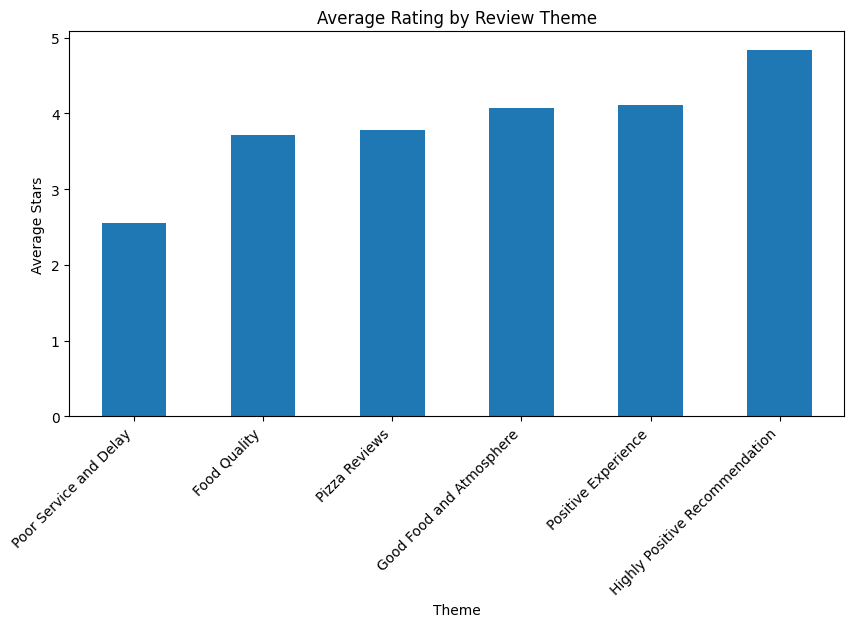

In [12]:
#average rating by cluster
import matplotlib.pyplot as plt

rating_plot = df.groupby("cluster_name")["stars"].mean().sort_values()

plt.figure(figsize=(10, 5))
rating_plot.plot(kind="bar")
plt.title("Average Rating by Review Theme")
plt.xlabel("Theme")
plt.ylabel("Average Stars")
plt.xticks(rotation=45, ha="right")
plt.show()

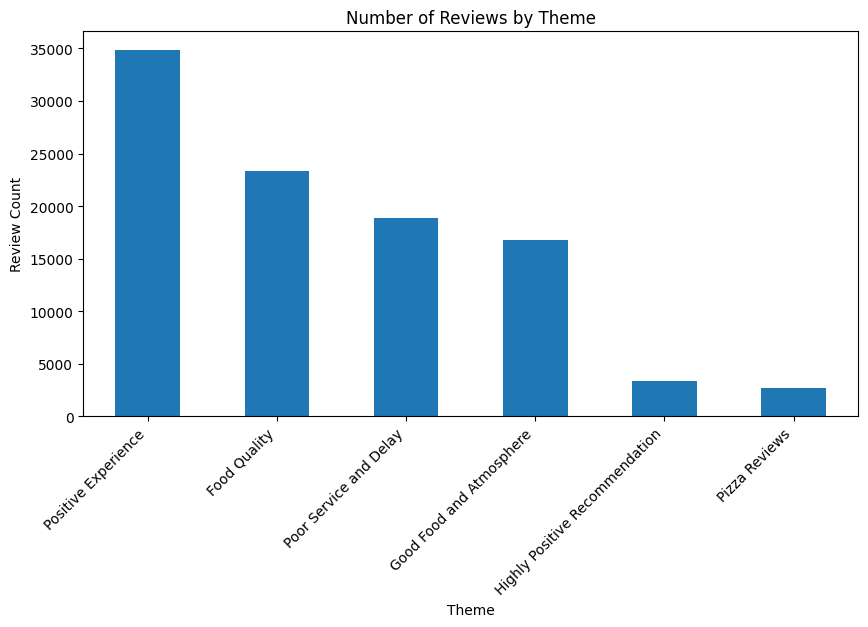

In [13]:
#review count by cluster
count_plot = df["cluster_name"].value_counts()
plt.figure(figsize=(10, 5))
count_plot.plot(kind="bar")
plt.title("Number of Reviews by Theme")
plt.xlabel("Theme")
plt.ylabel("Review Count")
plt.xticks(rotation=45, ha="right")
plt.show()

In [14]:
#sample reviews from the worst theme
worst_reviews = df[df["cluster_name"] == "Poor Service and Delay"]["text"].head(10)

for i, review in enumerate(worst_reviews, 1):
    print(f"\nReview {i}")
    print(review[:400])


Review 1
First time waxing. I read all the other reviews and decided to trust yelp. Not disappointed. It was extremely fast and even though it was a little painful I am sure it would have been worse elsewhere. Great customer service, I will be going back.

Review 2
Absolutely horrible location. The lady that states your order had no smile on her face and was like a robot. Barely 1 scoop of rice in the bowl and she doesn't even give you a chance to let her know you want the veggies. When you do tell her she rolls her eyes. 

Worst experience at a chipotle ever. Avoid this location at all cost.

Review 3
Visited this place for the first time on yesterday.  Very bad service....long wait.....messy server......nasty drink station with most drinks out.   I realize that its new and they have kinks to work out...will give it a few weeks and try again.

Review 4
1st time trying the Japadog. I must have chosen the wrong one because I was extremely disappointed with the #5.  I see Japadog in man

Reviews related to poor service, long wait times, and negative customer interactions have the lowest average ratings. This suggests that operational issues and service quality are more damaging to customer satisfaction than food-specific comments alone.

In [15]:
# Build summary table
summary_table = (
    df.groupby("cluster_name")["stars"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values("mean")
)

summary_table["mean"] = summary_table["mean"].round(2)

summary_table

,cluster_name,mean,count
4,Poor Service and Delay,2.56,18916
0,Food Quality,3.71,23333
3,Pizza Reviews,3.78,2725
1,Good Food and Atmosphere,4.07,16767
5,Positive Experience,4.11,34871
2,Highly Positive Recommendation,4.84,3388


In [16]:
# Filter low-rating reviews
low_rating_df = df[df["stars"] <= 2].copy()

print(low_rating_df.shape)
low_rating_df.head()

(22924, 5)


,stars,text,clean_text,cluster,cluster_name
3,1.0,Save your money and go across the street the f...,save money across street food way better taqui...,5,Good Food and Atmosphere
11,1.0,Absolutely horrible location. The lady that st...,absolutely horrible location lady states order...,3,Poor Service and Delay
17,1.0,Visited this place for the first time on yeste...,visited place first time yesterday bad service...,3,Poor Service and Delay
22,1.0,The food is what you'd expect from a Steak and...,food expect steak shake service unbearably slo...,5,Good Food and Atmosphere
26,2.0,I used them for pool propane delivery. They ch...,used pool propane delivery charged year tank r...,0,Positive Experience


In [17]:
# Count low-rating themes
low_theme_count = (
    low_rating_df["cluster_name"]
    .value_counts()
    .reset_index()
)

low_theme_count.columns = ["theme", "low_rating_count"]

low_theme_count

,theme,low_rating_count
0,Poor Service and Delay,11208
1,Positive Experience,4632
2,Food Quality,4270
3,Good Food and Atmosphere,2221
4,Pizza Reviews,546
5,Highly Positive Recommendation,47


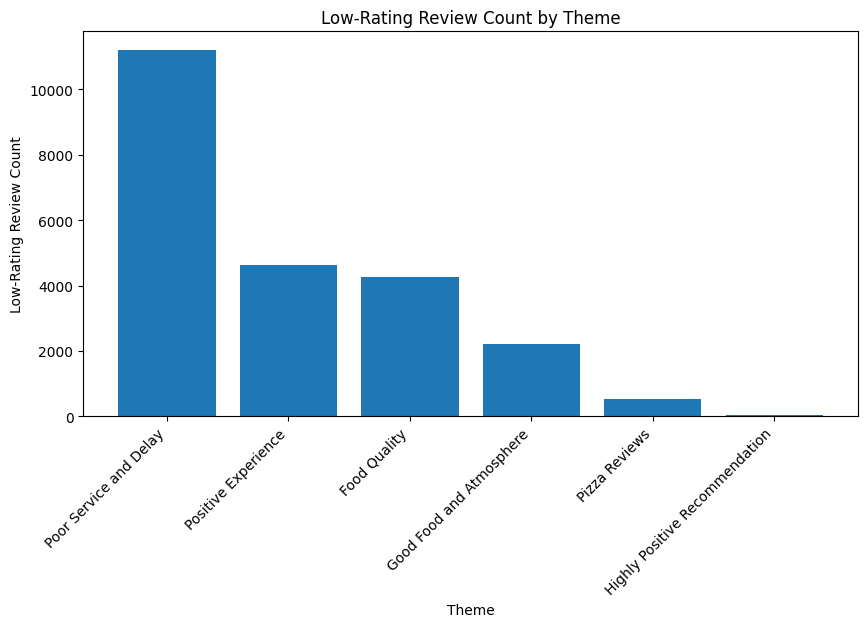

In [18]:
# Plot low-rating themes
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(low_theme_count["theme"], low_theme_count["low_rating_count"])
plt.title("Low-Rating Review Count by Theme")
plt.xlabel("Theme")
plt.ylabel("Low-Rating Review Count")
plt.xticks(rotation=45, ha="right")
plt.show()

In [19]:
# Show low-rating service complaints
worst_low_reviews = df[
    (df["cluster_name"] == "Poor Service and Delay") & (df["stars"] <= 2)
]["text"].head(10)

for i, review in enumerate(worst_low_reviews, 1):
    print(f"\nReview {i}")
    print(review[:400])


Review 1
Absolutely horrible location. The lady that states your order had no smile on her face and was like a robot. Barely 1 scoop of rice in the bowl and she doesn't even give you a chance to let her know you want the veggies. When you do tell her she rolls her eyes. 

Worst experience at a chipotle ever. Avoid this location at all cost.

Review 2
Visited this place for the first time on yesterday.  Very bad service....long wait.....messy server......nasty drink station with most drinks out.   I realize that its new and they have kinks to work out...will give it a few weeks and try again.

Review 3
I was not pleased to find out that my Credit Card Receipt from the restaurant added an extra dollar on the tip. I still have my receipt - It's an agreement and I consider this stealing. If this happens several a day - this would be Credit Card Fraud. 
I've tried to call and contact the manager. 
It happened 6.23.2019 - the waitress's name starts with an O
If someone rips me off. The expe

In [20]:
# Refresh summary table
summary_table = (
    df.groupby("cluster_name")["stars"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values("mean")
)

summary_table["mean"] = summary_table["mean"].round(2)

summary_table

,cluster_name,mean,count
4,Poor Service and Delay,2.56,18916
0,Food Quality,3.71,23333
3,Pizza Reviews,3.78,2725
1,Good Food and Atmosphere,4.07,16767
5,Positive Experience,4.11,34871
2,Highly Positive Recommendation,4.84,3388


In [21]:
# Rename review themes
cluster_names = {
    0: "Positive Experience",
    1: "Pizza-Specific Reviews",
    2: "Food Quality and Menu",
    3: "Service Problems and Delays",
    4: "Strong Recommendations",
    5: "Food and Atmosphere"}
df["cluster_name"] = df["cluster"].map(cluster_names)
df[["cluster", "cluster_name"]].head()

,cluster,cluster_name
0,3,Service Problems and Delays
1,0,Positive Experience
2,5,Food and Atmosphere
3,5,Food and Atmosphere
4,2,Food Quality and Menu


In [22]:
# Build final theme table
final_theme_table = summary_table.merge(
    low_theme_count,
    left_on="cluster_name",
    right_on="theme",
    how="left")
final_theme_table = final_theme_table.drop(columns="theme")
final_theme_table

,cluster_name,mean,count,low_rating_count
0,Poor Service and Delay,2.56,18916,11208
1,Food Quality,3.71,23333,4270
2,Pizza Reviews,3.78,2725,546
3,Good Food and Atmosphere,4.07,16767,2221
4,Positive Experience,4.11,34871,4632
5,Highly Positive Recommendation,4.84,3388,47


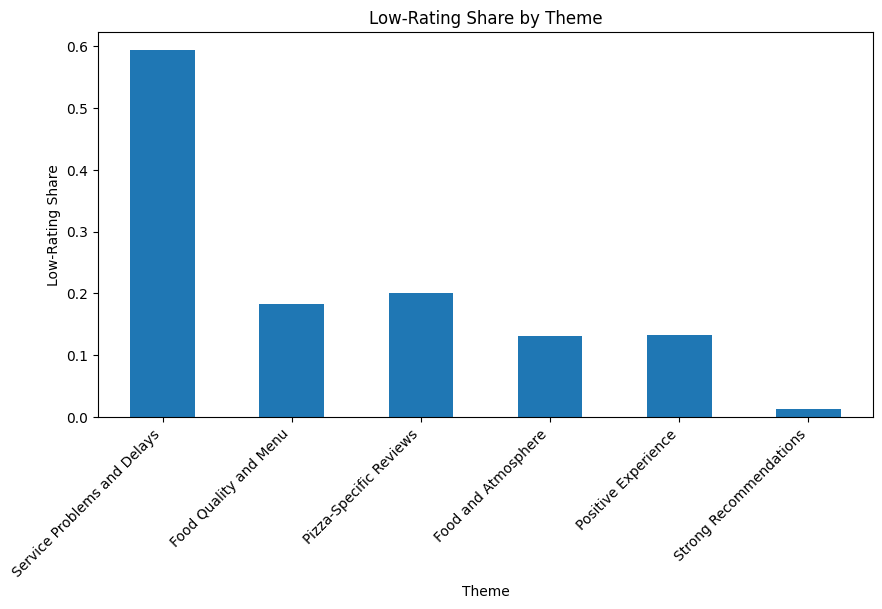

In [28]:
# Rebuild share and plot
final_theme_table["low_rating_share"] = (
    final_theme_table["low_rating_count"] / final_theme_table["count"]
)

final_theme_table["low_rating_share"] = (
    final_theme_table["low_rating_share"].round(3)
)

share_plot = final_theme_table.set_index("cluster_name")["low_rating_share"]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
share_plot.plot(kind="bar")
plt.title("Low-Rating Share by Theme")
plt.xlabel("Theme")
plt.ylabel("Low-Rating Share")
plt.xticks(rotation=45, ha="right")
plt.show()

Main finding
Reviews about poor service, long wait times, and negative customer interactions are the most damaging theme in this dataset. This theme has the lowest average rating and the highest concentration of low-rating reviews, suggesting that operational issues hurt customer satisfaction more than food-related topics alone.

In [32]:
# Show low-rating examples
examples = df[
    (df["cluster_name"] == "Service Problems and Delays") & (df["stars"] <= 2)
][["stars", "text"]].head(5)

examples

,stars,text
11,1.0,Absolutely horrible location. The lady that st...
17,1.0,Visited this place for the first time on yeste...
51,1.0,I was not pleased to find out that my Credit C...
66,2.0,This is just a review on service rather than f...
75,1.0,Wasted 30min of my life and couldn't even buy ...


In [33]:
# Print review examples
for i, row in examples.iterrows():
    print(f"\nReview {i}")
    print(f"Stars: {row['stars']}")
    print(row["text"][:500])


Review 11
Stars: 1.0
Absolutely horrible location. The lady that states your order had no smile on her face and was like a robot. Barely 1 scoop of rice in the bowl and she doesn't even give you a chance to let her know you want the veggies. When you do tell her she rolls her eyes. 

Worst experience at a chipotle ever. Avoid this location at all cost.

Review 17
Stars: 1.0
Visited this place for the first time on yesterday.  Very bad service....long wait.....messy server......nasty drink station with most drinks out.   I realize that its new and they have kinks to work out...will give it a few weeks and try again.

Review 51
Stars: 1.0
I was not pleased to find out that my Credit Card Receipt from the restaurant added an extra dollar on the tip. I still have my receipt - It's an agreement and I consider this stealing. If this happens several a day - this would be Credit Card Fraud. 
I've tried to call and contact the manager. 
It happened 6.23.2019 - the waitress's name starts with a

In [34]:
# Save final table
final_theme_table.to_csv("/content/final_theme_table.csv", index=False)

print("Saved: /content/final_theme_table.csv")

Saved: /content/final_theme_table.csv


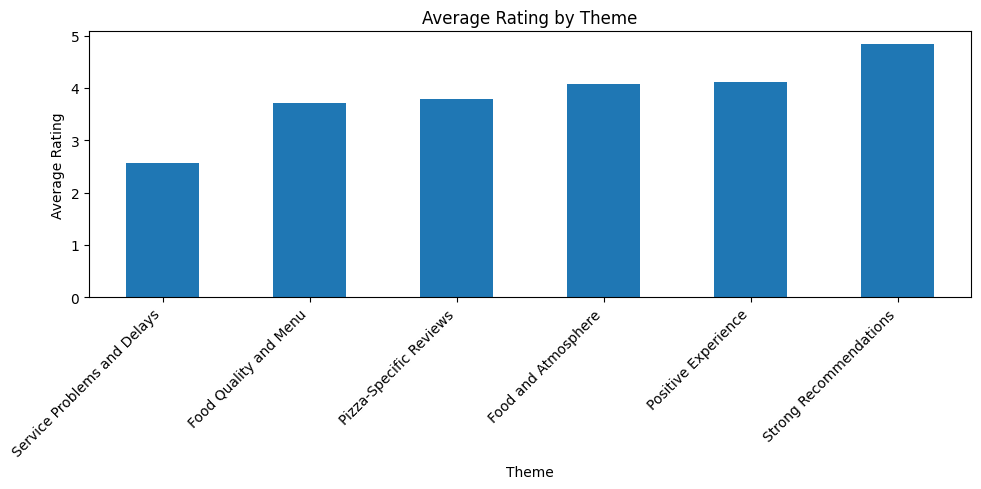

Saved: /content/average_rating_by_theme.png


In [36]:
# Plot average rating
avg_plot = final_theme_table.sort_values("mean").set_index("cluster_name")["mean"]

plt.figure(figsize=(10, 5))
avg_plot.plot(kind="bar")
plt.title("Average Rating by Theme")
plt.xlabel("Theme")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/average_rating_by_theme.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: /content/average_rating_by_theme.png")

In [38]:
# Summarize key findings
worst_theme = final_theme_table.sort_values("low_rating_share", ascending=False).iloc[0]
best_theme = final_theme_table.sort_values("mean", ascending=False).iloc[0]
print("Main Finding")
print(
    f"{worst_theme['cluster_name']} is the most damaging review theme. "
    f"It has the lowest average rating impact and the highest low-rating share "
    f"({worst_theme['low_rating_share']:.3f}).")
print("\nBest Theme")
print(
    f"{best_theme['cluster_name']} has the highest average rating "
    f"({best_theme['mean']:.2f}).")

Main Finding
Service Problems and Delays is the most damaging review theme. It has the lowest average rating impact and the highest low-rating share (0.593).

Best Theme
Strong Recommendations has the highest average rating (4.84).
